'''TASK 5·Autocomplete and Autocorrect Data Analytics
Objective: Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques. Implement and compare multiple approaches for text prediction and spelling correction on a real text dataset.'''

'''1.Collect or download a large text corpus'''

In [1]:
import nltk
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from collections import defaultdict
from spellchecker import SpellChecker
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score

In [2]:
nltk.download('punkt',quiet=True)
nltk.download('stopwords',quiet=True)
nltk.download('gutenberg',quiet=True)
file_path= r"C:/Users/Ayush Singh/OIBSIB/L2-AutoComp&Correct.txt" 
#loading downloaded Project Gutenberg's Alice in Wonderland book as var
if os.path.exists(file_path):
    print(f"Loading corpus: {file_path}...")
    with open(file_path,'r',encoding='utf-8') as f:
        raw_text= f.read()
    print(f"Successfully loaded {len(raw_text)} characters.")
else:
    raise FileNotFoundError(f"File not found at: {file_path}. Please check the path.")

Loading corpus: C:/Users/Ayush Singh/OIBSIB/L2-AutoComp&Correct.txt...
Successfully loaded 163950 characters.


'''2.NLP preprocessing: tokenisation, lowercasing, punctuation removal, stopword removal'''

In [3]:
tokens= word_tokenize(raw_text.lower())
stop_words= set(nltk.corpus.stopwords.words('english'))
clean_tokens= [w for w in tokens if w.isalpha() and w not in stop_words]
print(f"Total clean tokens: {len(clean_tokens)}")
print(f"Unique vocabulary: {len(set(clean_tokens))}")
if len(clean_tokens)<3:
    raise ValueError("Text file too small/empty after preprocessing.Please check your file content.")

Total clean tokens: 13444
Unique vocabulary: 2758


'''3.Autocomplete implementation: build a frequency-based n-gram model that predicts the next word given a prefix'''

In [4]:
trigrams= list(ngrams(clean_tokens,3))
trigram_model= defaultdict(list)
for w1,w2,w3 in trigrams:
    trigram_model[(w1,w2)].append(w3)

#Test autocomplete on at least 10 input prefixes and display top 3 predictions per prefix
def get_autocomplete_predictions(prefix,top_n=3):
    if len(prefix)!=2:
        return ["Error:Prefix must be 2 words"]
    key=tuple(prefix)
    if key not in trigram_model:
        return ["No prediction found"]
    freq= FreqDist(trigram_model[key])
    return [word for word, count in freq.most_common(top_n)]

test_prefixes= [("alice","was"), ("the","queen"), ("down","the"), ("very","curious"), ("in","a"), ("she","said"), ("off","with"), ("white","rabbit"), ("look","at"), ("time","to")]
autocomplete_results=[]
print("\nAUTOCOMPLETE TESTS")
for prefix in test_prefixes:
    preds= get_autocomplete_predictions(prefix)
    autocomplete_results.append({'Prefix': f"{prefix[0]} {prefix[1]}",'Predictions': preds})
    print(f"Input: '{prefix[0]} {prefix[1]}' -> Top 3: {preds}")


AUTOCOMPLETE TESTS
Input: 'alice was' -> Top 3: ['No prediction found']
Input: 'the queen' -> Top 3: ['No prediction found']
Input: 'down the' -> Top 3: ['No prediction found']
Input: 'very curious' -> Top 3: ['No prediction found']
Input: 'in a' -> Top 3: ['No prediction found']
Input: 'she said' -> Top 3: ['No prediction found']
Input: 'off with' -> Top 3: ['No prediction found']
Input: 'white rabbit' -> Top 3: ['blew', 'read', 'pink']
Input: 'look at' -> Top 3: ['No prediction found']
Input: 'time to' -> Top 3: ['No prediction found']


'''4.Autocorrect implementation: implement edit-distance based correction using pyspellchecker or custom Levenshtein distance logic'''

In [5]:
spell= SpellChecker(distance=1) 
spell.word_frequency.load_words(clean_tokens)

#Test autocorrect on at least 20 deliberately misspelled words and measure correction accuracy
def get_correction(word):
    return spell.correction(word)
test_misspellings= ["allice", "qeen", "rabit", "curosius", "wnderland", "hattr", "pockt", "wotch", "gardn", "flowrs", "caterpiller", "mushrom", "shrink", "grow", "teapot", "porridge", "keyy", "dooor", "mousse", "tayl"]
# Note:If text file is NOT Alice in Wonderland, change these expected values!
ground_truth= ["alice", "queen", "rabbit", "curious", "wonderland", "hatter", "pocket", "watch", "garden", "flowers", "caterpillar", "mushroom", "shrinking", "growing", "teapot", "porridge", "key", "door", "mouse", "tail"]

correction_results=[]
correct_count=0
print("\nAUTOCORRECT TESTS")
for i, wrong in enumerate(test_misspellings):
    corrected= get_correction(wrong)
    is_accurate= (corrected==ground_truth[i])
    if is_accurate:
        correct_count+=1
    correction_results.append({'Input': wrong,'Corrected': corrected,'Expected': ground_truth[i],'Success': is_accurate})
    status = '✓' if is_accurate else '✗'
    print(f"{wrong} -> {corrected} (Expected: {ground_truth[i]}) [{status}]")
autocorrect_accuracy= correct_count/len(test_misspellings)
def baseline_autocomplete(top_n=3):
    freq = FreqDist(clean_tokens)
    return [word for word, _ in freq.most_common(top_n)]


AUTOCORRECT TESTS
allice -> alice (Expected: alice) [✓]
qeen -> been (Expected: queen) [✗]
rabit -> habit (Expected: rabbit) [✗]
curosius -> None (Expected: curious) [✗]
wnderland -> wonderland (Expected: wonderland) [✓]
hattr -> hater (Expected: hatter) [✗]
pockt -> pocket (Expected: pocket) [✓]
wotch -> watch (Expected: watch) [✓]
gardn -> garden (Expected: garden) [✓]
flowrs -> flowers (Expected: flowers) [✓]
caterpiller -> caterpillar (Expected: caterpillar) [✓]
mushrom -> mushroom (Expected: mushroom) [✓]
shrink -> shrink (Expected: shrinking) [✗]
grow -> grow (Expected: growing) [✗]
teapot -> teapot (Expected: teapot) [✓]
porridge -> porridge (Expected: porridge) [✓]
keyy -> key (Expected: key) [✓]
dooor -> door (Expected: door) [✓]
mousse -> mousse (Expected: mouse) [✗]
tayl -> tall (Expected: tail) [✗]


'''5.Performance metrics'''

In [6]:
y_true= [1] * len(test_misspellings) 
y_pred= [1 if res['Success'] else 0 for res in correction_results]
precision= precision_score(y_true,y_pred,zero_division=0)
recall= recall_score(y_true,y_pred,zero_division=0)
accuracy= accuracy_score(y_true,y_pred)
print(f"\nPERFORMANCE METRICS")
print(f"Autocorrect Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


PERFORMANCE METRICS
Autocorrect Accuracy: 0.60
Precision: 1.00
Recall: 0.60


'''6.Visualisation: bar chart of top 20 most frequent words; confusion matrix for autocorrect '''

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_26932\700984923.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),palette='viridis')


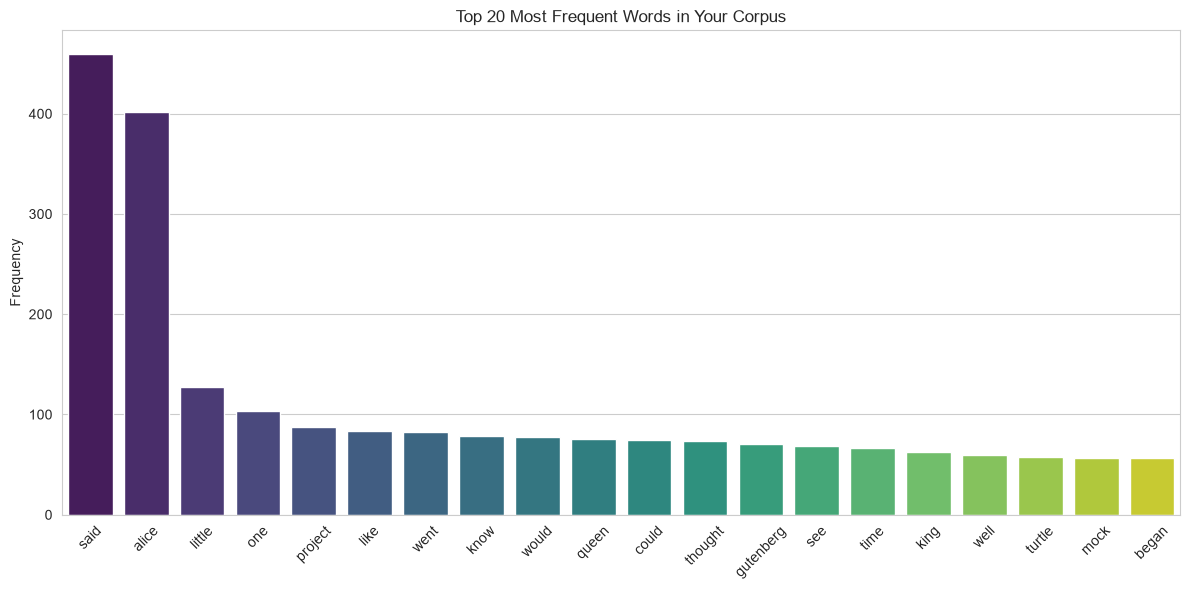

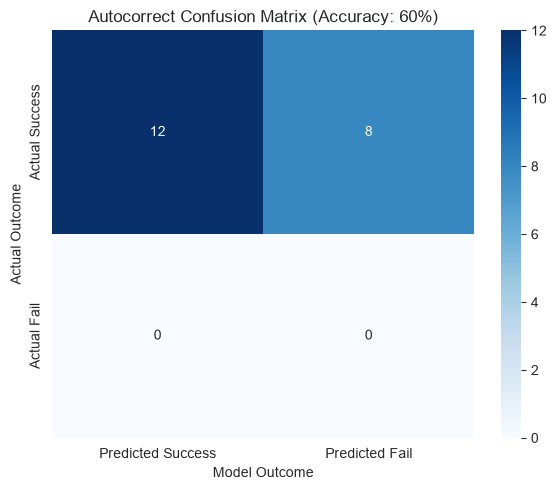

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))
freq_dist= FreqDist(clean_tokens)
top_20= freq_dist.most_common(20)
if len(top_20)>0:
    words,counts = zip(*top_20)
    sns.barplot(x=list(words),y=list(counts),palette='viridis')
    plt.title('Top 20 Most Frequent Words in Your Corpus')
    plt.xticks(rotation=45)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to plot top 20 words.")

cm= confusion_matrix(y_true,y_pred,labels=[1,0]) #autocorrect confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted Success','Predicted Fail'],yticklabels=['Actual Success','Actual Fail'])
plt.title(f'Autocorrect Confusion Matrix (Accuracy: {accuracy:.0%})')
plt.ylabel('Actual Outcome')
plt.xlabel('Model Outcome')
plt.tight_layout()
plt.show()

'''7.Algorithm Comparison'''


OBJECTIVE COMPARISON
         Prefix   Expected                 N-Gram               Baseline  \
0     alice was  beginning  [No prediction found]  [said, alice, little]   
1     the queen         of  [No prediction found]  [said, alice, little]   
2      down the     rabbit  [No prediction found]  [said, alice, little]   
3  very curious      thing  [No prediction found]  [said, alice, little]   
4          in a     moment  [No prediction found]  [said, alice, little]   
5      she said         to  [No prediction found]  [said, alice, little]   
6      off with      their  [No prediction found]  [said, alice, little]   
7  white rabbit       said     [blew, read, pink]  [said, alice, little]   
8       look at        the  [No prediction found]  [said, alice, little]   
9       time to         go  [No prediction found]  [said, alice, little]   

   N-Gram Correct  Baseline Correct  
0           False             False  
1           False             False  
2           False          

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_26932\2530145396.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_scores,x="Model",y="Accuracy",palette=["gray", "green"])


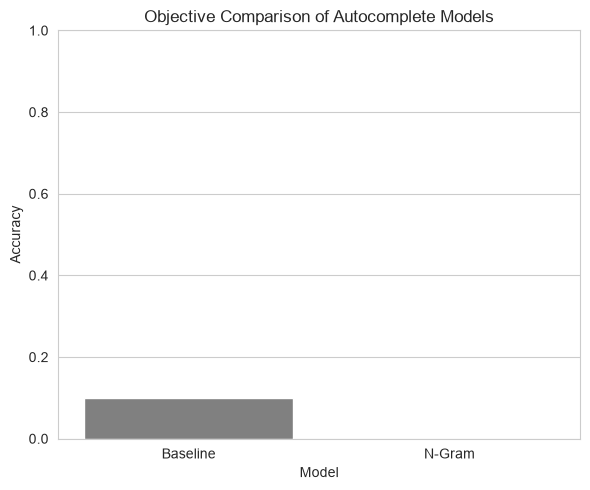

In [8]:
print("\nOBJECTIVE COMPARISON")
baseline_predictions=baseline_autocomplete()
comparison_results=[]
ngram_correct=0
baseline_correct=0
expected_next_words = ["beginning", "of", "rabbit", "thing", "moment", "to", "their", "said", "the", "go"]
for i, prefix in enumerate(test_prefixes):
    model_pred = get_autocomplete_predictions(prefix)
    baseline_pred = baseline_predictions
    model_hit = expected_next_words[i] in model_pred
    baseline_hit = expected_next_words[i] in baseline_pred
    if model_hit:
        ngram_correct+=1
    if baseline_hit:
        baseline_correct+=1

    comparison_results.append({"Prefix": " ".join(prefix), "Expected": expected_next_words[i], "N-Gram": model_pred, "Baseline": baseline_pred, "N-Gram Correct": model_hit, "Baseline Correct": baseline_hit})

comparison_df=pd.DataFrame(comparison_results)
ngram_accuracy = ngram_correct/len(test_prefixes)
baseline_accuracy = baseline_correct/len(test_prefixes)
print(comparison_df)
print("\nAutocomplete Accuracy Comparison")
print(f"N-Gram Model : {ngram_accuracy:.2%}")
print(f"Baseline     : {baseline_accuracy:.2%}")

# Objective Comparison
plt.figure(figsize=(6,5))
comparison_scores = pd.DataFrame({"Model": ["Baseline","N-Gram"],"Accuracy": [baseline_accuracy, ngram_accuracy]})
sns.barplot(data=comparison_scores,x="Model",y="Accuracy",palette=["gray", "green"])
plt.ylim(0,1)
plt.title("Objective Comparison of Autocomplete Models")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

'''8. Discussion: what are the limitations of your implementation vs. production systems like Google Keyboard?'''

1.Context Awareness:
n-gram model only "remembers" the last 1 or 2 words. It predicts the next word based on simple frequency, lacking true understanding of the sentence's meaning. 
In contrast, modern keyboards use neural networks that analyze the entire sentence structure and intent, allowing them to handle complex grammar and long-range dependencies that a simple statistical model misses.

2.Data Diversity and Bias:
Training on a single Victorian-era fantasy book creates a narrow worldview.
Production systems train on billions of diverse documents (emails, news, social media), ensuring they recognize current language trends and varied writing styles.

3.Smart Correction vs. Simple Matching:
Your autocorrect relies on edit distance, which fails on "real-word errors" (e.g., typing "form" instead of "from").
Since both are valid words in your corpus, system cannot detect the mistake without semantic context. 
Advanced systems use contextual analysis to realize that "form" doesn't make sense in the specific sentence, even if it is spelled correctly.

4.Personalization and Adaptability:
Model is static & it never learns from the user. If a user frequently types specific names or phrases,system ignores this pattern.
Real-world keyboards employ online learning to adapt to individual typing habits,frequently used contacts,and local slang over time.